In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, 'src')
import post_production as pp

import seaborn as sns
from chainconsumer import ChainConsumer

In [2]:
ChainConsumer.__version__

'0.34.0'

In [3]:
def plot_corner_B(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,2,:].flatten()
        NN = chain[:,3,:].flatten()
        b1S = chain[:,4,:].flatten()
        s_fogS = chain[:,5,:].flatten()
        NS = chain[:,6,:].flatten()
        
        data = np.vstack([f_nl, b1N, b1S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$"]
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1B = chain[:,1,:].flatten()
        b2 = chain[:,2,:].flatten()
        bs = chain[:,3,:].flatten()
        a1 = chain[:,4,:].flatten()
        a2 = chain[:,5,:].flatten()
        
        data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    

In [4]:
def plot_corner_B_prior(chain, pop=None, save=None, annotate=None, xy=(200,200)):
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
    
    f_nl = chain[:,0,:].flatten()
    b1B = chain[:,1,:].flatten()
    b2 = chain[:,2,:].flatten()
    bs = chain[:,3,:].flatten()
    a1 = chain[:,4,:].flatten()
    a2 = chain[:,5,:].flatten()
    
    data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
    labels=[r"$f_{\rm NL}$",
            r"$b_1^B$",
            r"$b_2$",
            r"$b_{s2}$",
            r"$\alpha_1$",
            r"$\alpha_2$"]
        
    nsample = 5000
    data2 = np.vstack([np.random.uniform(-1000, 1000, size=nsample),
                       np.random.normal(2.3, 0.5, size=nsample),
                       np.random.normal(-3.7, 5, size=nsample),
                       np.random.normal(-0.7, 0.6, size=nsample),
                       np.random.uniform(-1.5, 1.5, size=nsample),
                       np.random.uniform(-1.5, 1.5, size=nsample)]).transpose()    
    
    extents = {}
    for i,l in enumerate(labels):
        extents[l] = [data[:,i].min(), data[:,i].max()]
    #extents = None
    
    c = ChainConsumer()
    c.add_chain(data2, parameters=labels, name="Prior")
    c.add_chain(data, parameters=labels, name="Posterior")

    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True, True], bar_shade=[False, False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    c.add_chain(data2, parameters=labels, name="Prior")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    

In [5]:
def plot_corner_PplusB(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$\sigma_{\rm FoG}\, (\rm NGC)$",
                r"$N\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$",
                r"$\sigma_{\rm FoG}\, (\rm SGC)$",
                r"$N\, (\rm SGC)$"]
        
        tick_font_size=10
        label_font_size=15
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_size, label_font_size=label_font_size)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        data = np.vstack([f_nl, b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B \, (\rm NGC)$",
                r"$b_2 \, (\rm NGC)$",
                r"$b_{s2} \, (\rm NGC)$",
                r"$c_1 \, (\rm NGC)$",
                r"$\alpha_1 \, (\rm NGC)$",
                r"$\alpha_2 \, (\rm NGC)$",
                r"$b_1^B \, (\rm SGC)$",
                r"$b_2 \, (\rm SGC)$",
                r"$b_{s2} \, (\rm SGC)$",
                r"$c_1 \, (\rm SGC)$",
                r"$\alpha_1 \, (\rm SGC)$",
                r"$\alpha_2 \, (\rm SGC)$"]
    else:
        data = np.vstack([f_nl, b1B, b2, bs, c1, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [6]:
def plot_corner_PplusB_noc1(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        a1N = chain[:,11,:].flatten()
        a2N = chain[:,12,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,13,:].flatten()
        bsS = chain[:,14,:].flatten()
        a1S = chain[:,15,:].flatten()
        a2S = chain[:,16,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$\sigma_{\rm FoG}\, (\rm NGC)$",
                r"$N\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$",
                r"$\sigma_{\rm FoG}\, (\rm SGC)$",
                r"$N\, (\rm SGC)$"]
        
        tick_font_size=10
        label_font_size=15
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        a1 = chain[:,7,:].flatten()
        a2 = chain[:,8,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_size, label_font_size=label_font_size)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        data = np.vstack([f_nl, b1BN, b2N, bsN, a1N, a2N, b1BS, b2S, bsS, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B \, (\rm NGC)$",
                r"$b_2 \, (\rm NGC)$",
                r"$b_{s2} \, (\rm NGC)$",
                r"$\alpha_1 \, (\rm NGC)$",
                r"$\alpha_2 \, (\rm NGC)$",
                r"$b_1^B \, (\rm SGC)$",
                r"$b_2 \, (\rm SGC)$",
                r"$b_{s2} \, (\rm SGC)$",
                r"$\alpha_1 \, (\rm SGC)$",
                r"$\alpha_2 \, (\rm SGC)$"]
    else:
        data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [7]:
def hist_chain(chain, length=12):
    f_nl = chain[:,0,:]
    
    for i in range(length):
        plt.hist(f_nl[:,i], bins=25, density=True, histtype='step', label=f'{i}')
    
    plt.legend()
    plt.show()
    
    R = pp.gelman_rubin_R(f_nl)
    print(R - 1)

In [8]:
def fNL_posterior_comparison_smooth(ch1, ch2, name1='FKP', name2='Optimal', save=None, ci95=None, annotate=None, xy=(100,100), xlim=None):
    from matplotlib.pyplot import rc
    import matplotlib.font_manager
    rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
    rc('mathtext', **{'fontset':'cm'})
    rc('text', usetex=True)
    rc('legend',**{'fontsize':'18'})
    matplotlib.rcParams['axes.linewidth'] = 1.5
    matplotlib.rcParams['axes.labelsize'] = 20
    matplotlib.rcParams['xtick.labelsize'] = 15
    matplotlib.rcParams['ytick.labelsize'] = 15
    matplotlib.rcParams['legend.fontsize'] = 15
    #matplotlib.rcParams['legend.title_fontsize'] = 25
    matplotlib.rcParams['xtick.major.size'] = 5
    matplotlib.rcParams['ytick.major.size'] = 5
    matplotlib.rcParams['xtick.minor.size'] = 2.5
    matplotlib.rcParams['ytick.minor.size'] = 2.5
    matplotlib.rcParams['xtick.major.width'] = 1.5
    matplotlib.rcParams['ytick.major.width'] = 1.5
    matplotlib.rcParams['xtick.minor.width'] = 1.5
    matplotlib.rcParams['ytick.minor.width'] = 1.5
    matplotlib.rcParams['axes.titlesize'] = 30
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    
    ch1 = ch1.flatten()
    ch2 = ch2.flatten()
    
    sns.distplot(ch1, hist=False, kde=True, label=name1,
                 color = 'tomato',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashed'})
    sns.distplot(ch2, hist=False, kde=True, label=name2,
                 color = 'darkblue',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dotted'})

    if ci95 is not None:
        plt.axvline(ci95[0,0], linestyle="dashed", color="tomato")
        plt.axvline(ci95[0,1], linestyle="dashed", color="tomato")
        plt.axvline(ci95[1,0], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[1,1], linestyle="dotted", color="darkblue")
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels')
    
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.xlabel("$f_{\\rm NL}$")
    plt.ylabel("$p( f_{\\rm NL} )$")
    plt.tick_params(axis='y', which='both', left=False, right=False, 
                    labelleft=False)
    plt.legend(frameon=False)
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

def fNL_posterior_3comparison_smooth(ch1, ch2, ch3, name1, name2, name3, save=None, ci95=None, annotate=None, xy=(100,100), xlim=None, loc=2):
    from matplotlib.pyplot import rc
    import matplotlib.font_manager
    rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
    rc('mathtext', **{'fontset':'cm'})
    rc('text', usetex=True)
    rc('legend',**{'fontsize':'18'})
    matplotlib.rcParams['axes.linewidth'] = 1.5
    matplotlib.rcParams['axes.labelsize'] = 20
    matplotlib.rcParams['xtick.labelsize'] = 15
    matplotlib.rcParams['ytick.labelsize'] = 15
    matplotlib.rcParams['legend.fontsize'] = 15
    #matplotlib.rcParams['legend.title_fontsize'] = 25
    matplotlib.rcParams['xtick.major.size'] = 5
    matplotlib.rcParams['ytick.major.size'] = 5
    matplotlib.rcParams['xtick.minor.size'] = 2.5
    matplotlib.rcParams['ytick.minor.size'] = 2.5
    matplotlib.rcParams['xtick.major.width'] = 1.5
    matplotlib.rcParams['ytick.major.width'] = 1.5
    matplotlib.rcParams['xtick.minor.width'] = 1.5
    matplotlib.rcParams['ytick.minor.width'] = 1.5
    matplotlib.rcParams['axes.titlesize'] = 30
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    
    ch1 = ch1.flatten()
    ch2 = ch2.flatten()
    ch3 = ch3.flatten()
    
    sns.distplot(ch1, hist=False, kde=True, label=name1,
                 color = 'tomato',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashed'})
    sns.distplot(ch2, hist=False, kde=True, label=name2,
                 color = 'darkblue',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dotted'})
    sns.distplot(ch3, hist=False, kde=True, label=name3,
                 color = 'green',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashdot'})

    if ci95 is not None:
        plt.axvline(ci95[0,0], linestyle="dashed", color="tomato")
        plt.axvline(ci95[0,1], linestyle="dashed", color="tomato")
        plt.axvline(ci95[1,0], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[1,1], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[2,0], linestyle="dotted", color="green")
        plt.axvline(ci95[2,1], linestyle="dotted", color="green")
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels')
    
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.xlabel("$f_{\\rm NL}$")
    plt.ylabel("$p( f_{\\rm NL} )$")
    plt.tick_params(axis='y', which='both', left=False, right=False, 
                    labelleft=False)
    plt.legend(frameon=False, loc=loc)
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [9]:
def plot_corner_PplusB_field(chain, sample, field=None, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        assert field is not None
        assert field in ['N', 'S']
        
        f_nl = chain[:,0,:].flatten()
        
        if field == 'N':
            b1P = chain[:,1,:].flatten()
            sigma_fog = chain[:,5,:].flatten()
            N = chain[:,6,:].flatten()
            
            b1B = chain[:,2,:].flatten()
            b2 = chain[:,9,:].flatten()
            bs = chain[:,10,:].flatten()
            c1 = chain[:,11,:].flatten()
            a1 = chain[:,12,:].flatten()
            a2 = chain[:,13,:].flatten()
            
            
        else:
            b1P = chain[:,3,:].flatten()
            sigma_fog = chain[:,7,:].flatten()
            N = chain[:,8,:].flatten()
        
            b1B = chain[:,4,:].flatten()
            b2 = chain[:,14,:].flatten()
            bs = chain[:,15,:].flatten()
            c1 = chain[:,16,:].flatten()
            a1 = chain[:,17,:].flatten()
            a2 = chain[:,18,:].flatten()
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
    data = np.vstack([f_nl, b1P, sigma_fog, N, b1B, b2, bs, c1, a1, a2]).transpose()
    labels=[r"$f_{\rm NL}$",
            r"$b_1^P$",
            r"$\sigma_{\rm FoG}$",
            r"$N$",
            "$b_1^B$",
            r"$b_2$",
            r"$b_{s2}$",
            r"$c_1$",
            r"$\alpha_1$",
            r"$\alpha_2$"]
        
    tick_font_sizeB =7
    label_font_sizeB=15
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [10]:
def plot_corner_PplusB_all(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS, 
                          b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm N)$",
                r"$\sigma_{\rm FoG}\, (\rm N)$",
                r"$N\, (\rm N)$",
                r"$b_1\, (\rm S)$",
                r"$\sigma_{\rm FoG}\, (\rm S)$",
                r"$N\, (\rm S)$",
                r"$b_1^B \, (\rm N)$",
                r"$b_2 \, (\rm N)$",
                r"$b_{s2} \, (\rm N)$",
                r"$c_1 \, (\rm N)$",
                r"$\alpha_1 \, (\rm N)$",
                r"$\alpha_2 \, (\rm N)$",
                r"$b_1^B \, (\rm S)$",
                r"$b_2 \, (\rm S)$",
                r"$b_{s2} \, (\rm S)$",
                r"$c_1 \, (\rm S)$",
                r"$\alpha_1 \, (\rm S)$",
                r"$\alpha_2 \, (\rm S)$"]
        
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N, 
                          b1B, b2, bs, c1, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    
def plot_corner_PplusB_compare(chain, chain2, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        f_nl2 = chain2[:,0,:].flatten()
        b1N2 = chain2[:,1,:].flatten()
        s_fogN2 = chain2[:,5,:].flatten()
        NN2 = chain2[:,6,:].flatten()
        b1S2 = chain2[:,3,:].flatten()
        s_fogS2 = chain2[:,7,:].flatten()
        NS2 = chain2[:,8,:].flatten()
        
        b1BN2 = chain2[:,2,:].flatten()
        b2N2 = chain2[:,9,:].flatten()
        bsN2 = chain2[:,10,:].flatten()
        c1N2 = chain2[:,11,:].flatten()
        a1N2 = chain2[:,12,:].flatten()
        a2N2 = chain2[:,13,:].flatten()
        
        b1BS2 = chain2[:,4,:].flatten()
        b2S2 = chain2[:,14,:].flatten()
        bsS2 = chain2[:,15,:].flatten()
        c1S2 = chain2[:,16,:].flatten()
        a1S2 = chain2[:,17,:].flatten()
        a2S2 = chain2[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS, 
                          b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        data1 = np.vstack([f_nl2, b1N2, s_fogN2, NN2, b1S2, s_fogS2, NS2, 
                          b1BN2, b2N2, bsN2, c1N2, a1N2, a2N2, b1BS2, b2S2, bsS2, c1S2, a1S2, a2S2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P\, (\rm N)$",
                r"$\sigma_{\rm FoG}\, (\rm N)$",
                r"$N\, (\rm N)$",
                r"$b_1^P\, (\rm S)$",
                r"$\sigma_{\rm FoG}\, (\rm S)$",
                r"$N\, (\rm S)$",
                r"$b_1^B \, (\rm N)$",
                r"$b_2 \, (\rm N)$",
                r"$b_{s^2} \, (\rm N)$",
                r"$c_1 \, (\rm N)$",
                r"$\alpha_1 \, (\rm N)$",
                r"$\alpha_2 \, (\rm N)$",
                r"$b_1^B \, (\rm S)$",
                r"$b_2 \, (\rm S)$",
                r"$b_{s^2} \, (\rm S)$",
                r"$c_1 \, (\rm S)$",
                r"$\alpha_1 \, (\rm S)$",
                r"$\alpha_2 \, (\rm S)$"]
        
        tick_font_sizeB =4
        label_font_sizeB=6
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        f_nl2 = chain2[:,0,:].flatten()
        b1P2 = chain2[:,1,:].flatten()
        sigma_fog2 = chain2[:,3,:].flatten()
        N2 = chain2[:,4,:].flatten()
        b1B2 = chain2[:,2,:].flatten()
        b22 = chain2[:,5,:].flatten()
        bs2 = chain2[:,6,:].flatten()
        c12 = chain2[:,7,:].flatten()
        a12 = chain2[:,8,:].flatten()
        a22 = chain2[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N, 
                          b1B, b2, bs, c1, a1, a2]).transpose()
        data1 = np.vstack([f_nl2, b1P2, sigma_fog2, N2, 
                          b1B2, b22, bs2, c12, a12, a22]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None

    from matplotlib import colors
    green = colors.to_hex('green')
    darkblue = colors.to_hex('darkblue')
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels, name="$P+B$")
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.add_chain(data1, parameters=labels, name="$P+{\\rm c}B$")
    #c.add_chain(data2, parameters=labels, name="Optimal")
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[False, False], bar_shade=[False, False], 
                summary = True, max_ticks=3, linestyles=['dashdot', 'dotted'], colors=[green,darkblue],
                tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB, legend_kwargs={'fontsize':25})
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

# Summary
- Constant noise is alwasy subtracted
- Analysis of Linear catalog

New results:

|FKP p=1.0|joint Interval|joint Width|NGC Interval|NGC Width|SGC Interval|SGC Width|
|---|---|---|---|---|---|---|
|Lin P only | (4)  19 <$f_{\rm NL}$< 53 (71) | 34 (67) | (6) 26 <$f_{\rm NL}$< 67 (87) | 41 (81) | (-36) -15 <$f_{\rm NL}$< 41 (72) | 56 (108) |
|Lin PB s3  | (3)  18 <$f_{\rm NL}$< 50 (66) | 32 (63) | (5) 25 <$f_{\rm NL}$< 63 (81) | 38 (76) | (-35) -10 <$f_{\rm NL}$< 42 (67) | 52 (102) |
|Lin PcB c9 | (-3) 14 <$f_{\rm NL}$< 49 (66) | 35 (69) | (3) 24 <$f_{\rm NL}$< 65 (85) | 41 (82) | (-41) -17 <$f_{\rm NL}$< 37 (66) | 54 (107) |
|Lin PB s3 mask |  |  | (3) 23 <$f_{\rm NL}$< 61 (78) | 38 (75) |  |  |


|Optimal p=1.0|joint Interval|joint Width|NGC Interval|NGC Width|SGC Interval|SGC Width|
|---|---|---|---|---|---|---|
|Lin P only | (-18) -4 <$f_{\rm NL}$< 27 (42) | 31 (60) | (-27)  -6 <$f_{\rm NL}$< 34 (62) | 40 (89) | (-35) -17 <$f_{\rm NL}$< 29 (55) | 46 (90) |
|Lin PB s3  | (-18) -6 <$f_{\rm NL}$< 20 (33) | 26 (51) | (-28) -9 <$f_{\rm NL}$< 26 (41) | 34 (69) | (-30) -11 <$f_{\rm NL}$< 27 (45) | 38 (75) |
|Lin PcB c9 | (-24) -9 <$f_{\rm NL}$< 22 (37) | 31 (61) | (-37) -12 <$f_{\rm NL}$< 30 (47) | 42 (84) | (-39) -18 <$f_{\rm NL}$< 27 (50) | 45 (89) |
|Lin PB s3 b2,c1 large p |  | | (-28) -9 <$f_{\rm NL}$< 26 (41) | 34 (69) |  |  |


|FKP p=1.6|joint Interval|joint Width|NGC Interval|NGC Width|SGC Interval|SGC Width|
|---|---|---|---|---|---|---|
|Lin P only | (6)  34 <$f_{\rm NL}$< 97 (129) | 63 (123) | (19) 49 <$f_{\rm NL}$< 125 (159) | 76 (140) | (-61) -22 <$f_{\rm NL}$< 78 (135) | 100 (196) |
|Lin PB s3  | (0)  31 <$f_{\rm NL}$< 89 (116) | 58 (116) | (10) 41 <$f_{\rm NL}$< 110 (145) | 69 (135) | (-60) -20 <$f_{\rm NL}$< 72 (123) | 92 (183) |
|Lin PcB c9 | (-7) 27 <$f_{\rm NL}$< 90 (118) | 63 (125) | (0) 41 <$f_{\rm NL}$< 118 (154) | 77 (154) | (-69) -30 <$f_{\rm NL}$< 67 (124) | 97 (193) |


|Optimal p=1.6|joint Interval|joint Width|NGC Interval|NGC Width|SGC Interval|SGC Width|
|---|---|---|---|---|---|---|
|Lin P only | (-43) -23 <$f_{\rm NL}$< 21 (44) | 44 (87) | (-80) -39 <$f_{\rm NL}$< 28 (54) | 67 (134) | (-51) -28 <$f_{\rm NL}$< 36 (74) | 64 (125) |
|Lin PB s3  | (-40) -23 <$f_{\rm NL}$< 14 (33) | 37 (73) | (-75) -41 <$f_{\rm NL}$< 16 (40) | 57 (115) | (-43) -22 <$f_{\rm NL}$< 31 (63) | 53 (106) |
|Lin PcB c9 | (-49) -30 <$f_{\rm NL}$< 14 (37) | 43 (87) | (-89) -48 <$f_{\rm NL}$< 20 (47) | 68 (136) | (-57) -36 <$f_{\rm NL}$< 27 (68) | 63 (125) |


Improvements wrt P-only:

|FKP p=1.0|joint improvement|NGC improvement|SGC improvement|
|---|---|---|---|
|Lin PB s3  |  -6% (-6%) | -7% (-6%) | -7% (-6%) |
|Lin PcB c9 |  +3% (+3%) |  0% (+2%) | -4% (-3%) |


|Optimal p=1.0|joint improvement|NGC improvement|SGC improvement|
|---|---|---|---|
|Lin PB s3  | -16% (-15%) | -15% (-22%) | -17% (-17%) |
|Lin PcB c9 |   0%  (+3%) |  +5% (-6%)  |   0%  (-2%) |


|FKP p=1.6|joint improvement|NGC improvement|SGC improvement|
|---|---|---|---|
|Lin PB s3  | -8% (-4%) | -9% (-4%)  | -8% (-7%) |
|Lin PcB c9 |  0% (+1%) | +1% (+10%) | -4% (-3%) |


|Optimal p=1.6|joint improvement|NGC improvement|SGC improvement|
|---|---|---|---|
|Lin PB s3  | -16% (-16%) | -15 (-14%) | -17% (-15%) |
|Lin PcB c9 |   0%   (0%) |  +1% (+1%) |  -2%   (0%) |

# PcB results

## NGC FKP p=1

In [11]:
output = "bis-fits/output-PplusB-compression/"

NGC P+cB FKP p=1


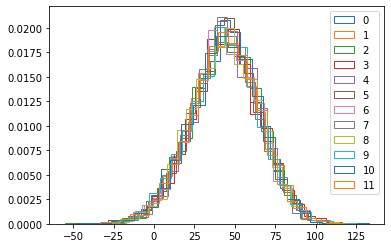

3.768117866687071e-05


In [12]:
print("NGC P+cB FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/NGC/data-SNsub/fkp/1.0/chain.npy"))

In [13]:
chain = np.load(output + "compression-9/NGC/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [0,11,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1
3.768117866687071e-05
[24.0144763  65.43904658]
[ 2.80505549 84.86639521]


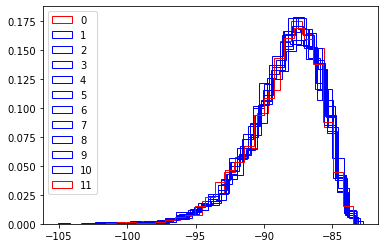

In [14]:
like = chain[:,14,:]

for i in range(12):
    if i in [0,11,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC optimal P p=1

NGC P+cB p=1


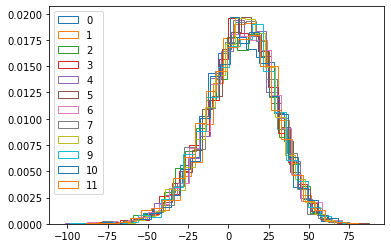

0.0009519453079789297


In [15]:
print("NGC P+cB p=1")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/NGC/data-SNsub/1.0/chain.npy"))

In [16]:
chain = np.load(output + "compression-9/NGC/data-SNsub/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [9,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1
0.0009519453079789297
[-12.27366112  29.79003191]
[-37.31303291  47.26506463]


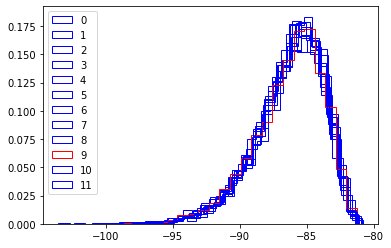

In [17]:
like = chain[:,14,:]

for i in range(12):
    if i in [9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC FKP p=1.6

In [18]:
output = "bis-fits/output-PplusB-compression/"

NGC P+cB FKP p=1.6


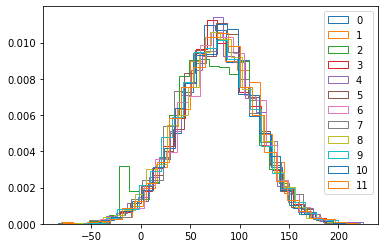

0.0016653006437590268


In [19]:
print("NGC P+cB FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/NGC/data-SNsub/fkp/1.6/chain.npy"))

In [20]:
chain = np.load(output + "compression-9/NGC/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [2,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1.6
0.0016653006437590268
[ 40.5592218 117.9810201]
[ -0.24850708 154.48299186]


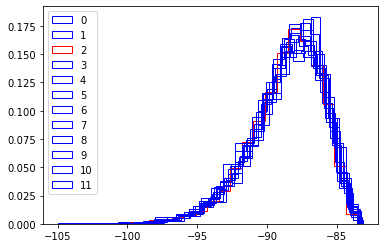

In [21]:
like = chain[:,14,:]

for i in range(12):
    if i in [2,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC optimal P p=1.6

NGC P+cB p=1.6


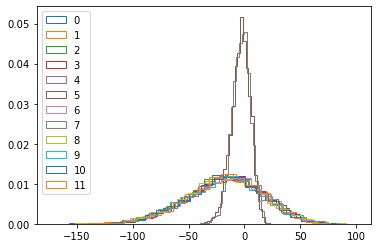

0.032183811283321484


In [22]:
print("NGC P+cB p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/NGC/data-SNsub/1.6/chain.npy"))

In [23]:
chain = np.load(output + "compression-9/NGC/data-SNsub/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [5,7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1.6
5.663006806710946e-05
[-48.16467513  20.49183479]
[-88.8489403  47.3898069]


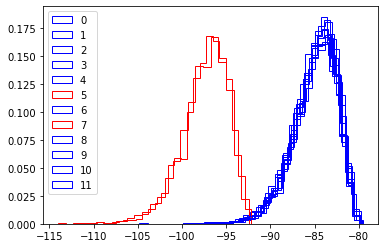

In [24]:
like = chain[:,14,:]

for i in range(12):
    if i in [5,7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC FKP p=1

In [25]:
output = "bis-fits/output-PplusB-compression/"

SGC P+cB FKP p=1


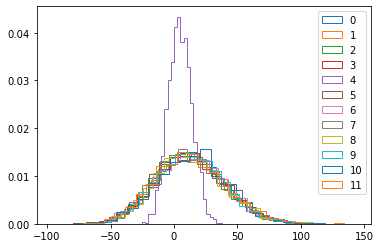

0.00795759538921792


In [26]:
print("SGC P+cB FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/SGC/data-SNsub/fkp/1.0/chain.npy"))

In [27]:
chain = np.load(output + "compression-9/SGC/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [4,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC FKP p=1
0.00013335929662861012
[-17.00236529  37.49226082]
[-40.8403439   66.08283428]


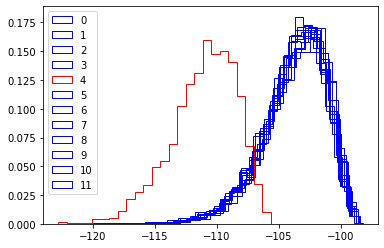

In [28]:
like = chain[:,14,:]

for i in range(12):
    if i in [4,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC optimal P p=1

SGC P+cB p=1


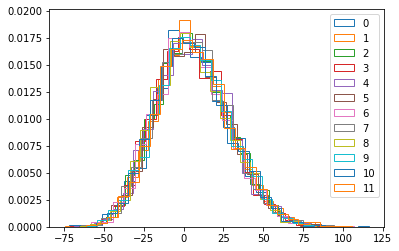

0.00022143940022001374


In [29]:
print("SGC P+cB p=1")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/SGC/data-SNsub/1.0/chain.npy"))

In [30]:
chain = np.load(output + "compression-9/SGC/data-SNsub/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [2,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC p=1
0.00022143940022001374
[-18.39193756  27.21359791]
[-38.72835162  50.38603865]


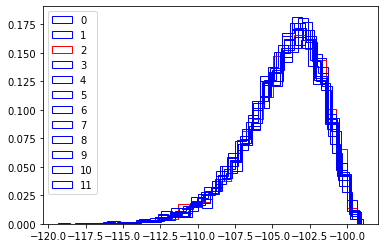

In [31]:
like = chain[:,14,:]

for i in range(12):
    if i in [2,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC FKP p=1.6

In [32]:
output = "bis-fits/output-PplusB-compression/"

SGC P+cB FKP p=1.6


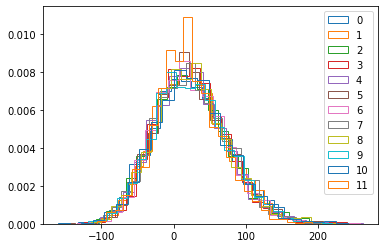

0.0007416193668952076


In [33]:
print("SGC P+cB FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/SGC/data-SNsub/fkp/1.6/chain.npy"))

In [34]:
chain = np.load(output + "compression-9/SGC/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC FKP p=1.6
0.0007416193668952076
[-30.07825283  67.32008294]
[-69.3435471  124.43833235]


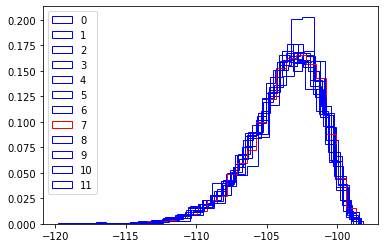

In [35]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC optimal P p=1.6

SGC P+cB p=1.6


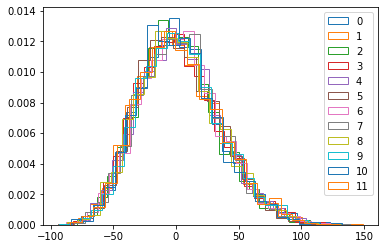

0.00047144752487549013


In [36]:
print("SGC P+cB p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-9/SGC/data-SNsub/1.6/chain.npy"))

In [37]:
chain = np.load(output + "compression-9/SGC/data-SNsub/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [9,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC p=1.6
0.00047144752487549013
[-36.00991087  27.40103245]
[-57.33508601  67.8337819 ]


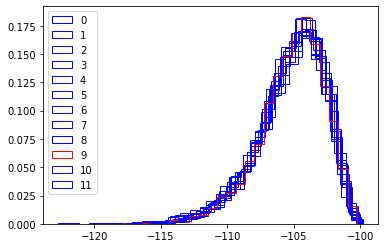

In [38]:
like = chain[:,14,:]

for i in range(12):
    if i in [9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint FKP p=1

In [39]:
output = "bis-fits/output-PplusB-compression/"

joint P+cB FKP p=1


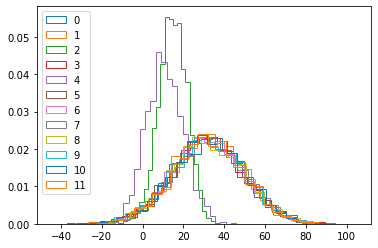

0.21306850433714852


In [40]:
print("joint P+cB FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-N9-S9/joint/data-SNsub/fkp/1.0/chain.npy"))

In [41]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [2,4,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint FKP p=1
0.00013187058742913926
[14.3348747  49.06667573]
[-2.56087968 66.24010657]


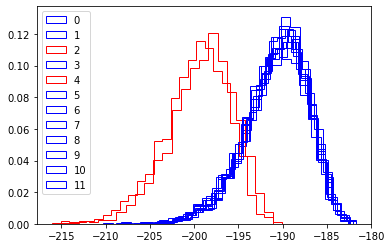

In [42]:
like = chain[:,23,:]

for i in range(12):
    if i in [2,4,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint optimal P p=1

joint P+cB p=1


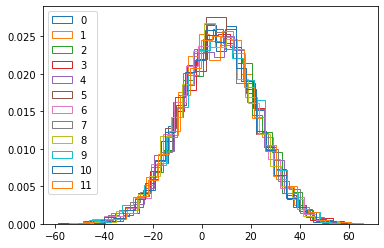

0.00043584279489938815


In [43]:
print("joint P+cB p=1")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-N9-S9/joint/data-SNsub/1.0/chain.npy"))

In [44]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [1,9,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint p=1
0.00043584279489938815
[-9.08537058 21.97292139]
[-24.48452367  36.86393292]


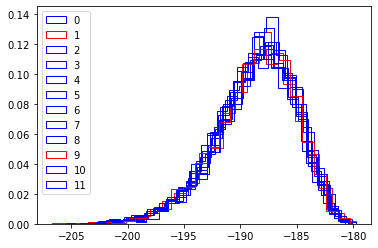

In [45]:
like = chain[:,23,:]

for i in range(12):
    if i in [1,9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint FKP p=1.6

In [46]:
output = "bis-fits/output-PplusB-compression/"

joint P+cB FKP p=1.6


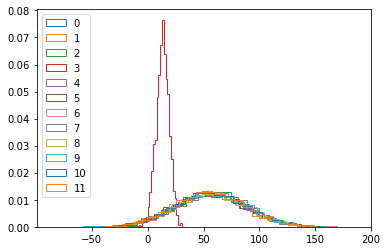

0.1667585493456023


In [47]:
print("joint P+cB FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-N9-S9/joint/data-SNsub/fkp/1.6/chain.npy"))

In [48]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [3,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint FKP p=1.6
1.3220587969930975e-05
[26.55405814 90.30402382]
[ -6.52515969 118.41996139]


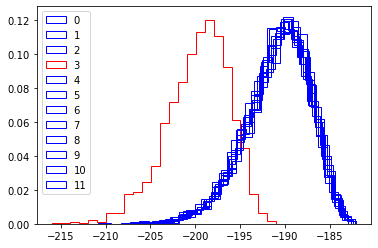

In [49]:
like = chain[:,23,:]

for i in range(12):
    if i in [3,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint optimal P p=1.6

joint P+cB p=1.6


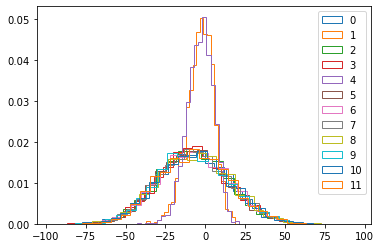

0.005186472124981245


In [50]:
print("joint P+cB p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-compression/compression-N9-S9/joint/data-SNsub/1.6/chain.npy"))

In [51]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [1,4,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint p=1.6
-0.00010622696017081878
[-30.2618145   14.25804724]
[-49.02946341  37.18614549]


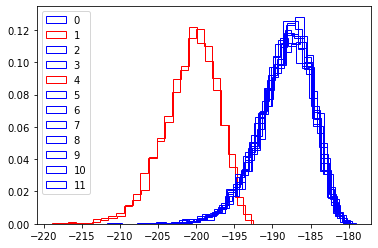

In [52]:
like = chain[:,23,:]

for i in range(12):
    if i in [1,4,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

# $3 k_f$ binning Results

## NGC FKP p=1

In [53]:
output = "bis-fits/output-PplusB-s3rebin/"

NGC P+B FKP p=1


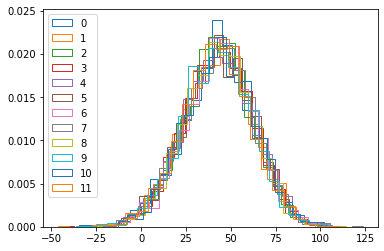

0.00041621435093874837


In [54]:
print("NGC P+B FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-fatsP/fkp/1.0/chain.npy"))

In [55]:
chain = np.load(output + "NGC/data-SNsub-fatsP/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1
0.00041621435093874837
[25.08459153 63.37455823]
[ 5.16685632 80.6661779 ]


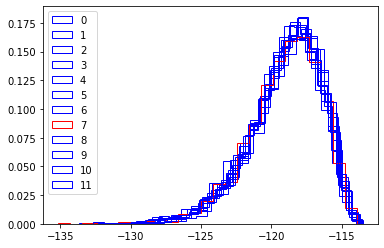

In [56]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC FKP p=1 with mask

In [57]:
output = "bis-fits/output-PplusB-s3rebin/"

NGC P+B FKP p=1


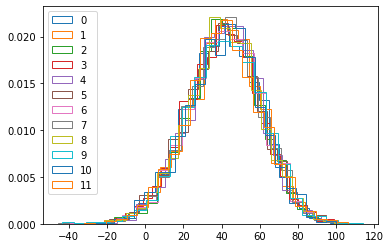

5.198871269906924e-05


In [58]:
print("NGC P+B FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-mask/fkp/1.0/chain.npy"))

In [59]:
chain = np.load(output + "NGC/data-SNsub-mask/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1
5.198871269906924e-05
[23.07333026 60.93362099]
[ 3.00493163 78.1600066 ]


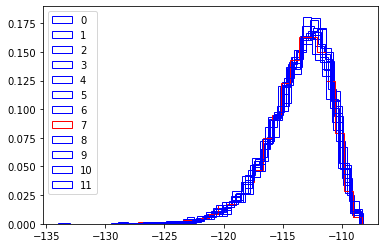

In [60]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC optimal P p=1

NGC P+B p=1


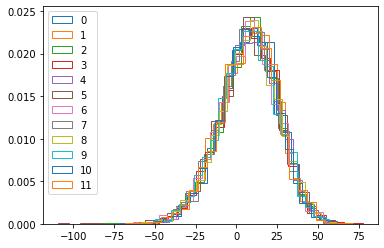

7.963586489401209e-05


In [61]:
print("NGC P+B p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-fatsP/1.0/chain.npy"))

In [62]:
chain = np.load(output + "NGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [6,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1
7.963586489401209e-05
[-8.7270779  26.13740496]
[-28.22055933  41.34932058]


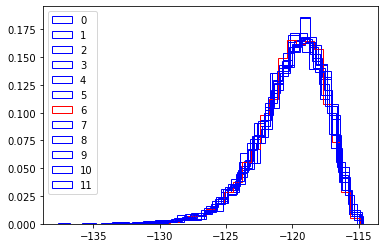

In [63]:
like = chain[:,14,:]

for i in range(12):
    if i in [6,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC optimal P p=1 $b_2 \in [-20,20]$, $c_1 \in [-100,100]$

NGC P+B p=1


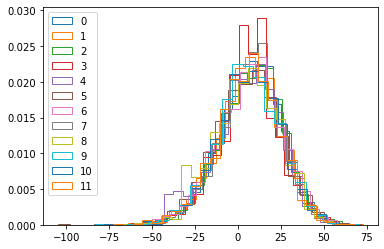

0.0024731303344196487


In [64]:
print("NGC P+B p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-b2c1large/1.0/chain.npy"))

In [65]:
chain = np.load(output + "NGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [4,8,3,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1
7.963586489401209e-05
[-8.7270779  26.13740496]
[-28.22055933  41.34932058]


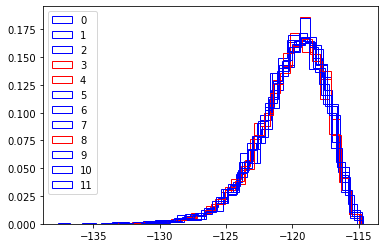

In [66]:
like = chain[:,14,:]

for i in range(12):
    if i in [4,8,3,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC FKP p=1.6

In [67]:
output = "bis-fits/output-PplusB-s3rebin/"

NGC P+B FKP p=1.6


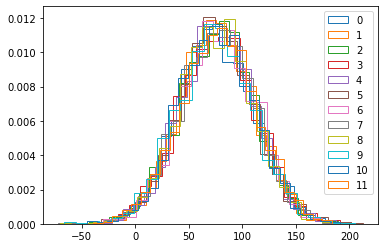

0.0004247242195432044


In [68]:
print("NGC P+B FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-fatsP/fkp/1.6/chain.npy"))

In [69]:
chain = np.load(output + "NGC/data-SNsub-fatsP/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC FKP p=1.6
0.0004247242195432044
[ 41.46951918 110.48659385]
[ 10.2233887  145.27510455]


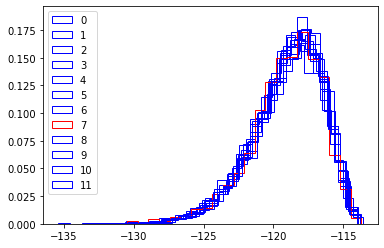

In [70]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## NGC optimal P p=1.6

NGC P+B p=1.6


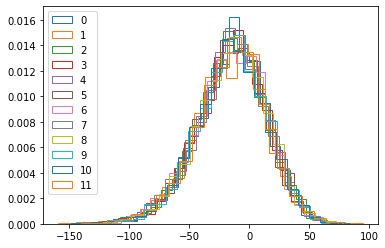

0.00012987211972603774


In [71]:
print("NGC P+B p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/NGC/data-SNsub-fatsP/1.6/chain.npy"))

In [72]:
chain = np.load(output + "NGC/data-SNsub-fatsP/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [6,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("NGC p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

NGC p=1.6
0.00012987211972603774
[-40.54950274  16.06368312]
[-75.36487869  39.56468007]


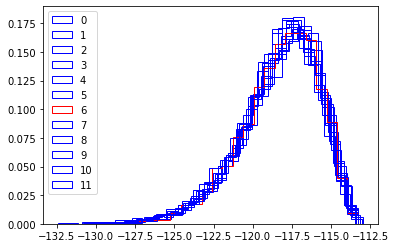

In [73]:
like = chain[:,14,:]

for i in range(12):
    if i in [6,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC FKP p=1

In [74]:
output = "bis-fits/output-PplusB-s3rebin/"

SGC P+B FKP p=1


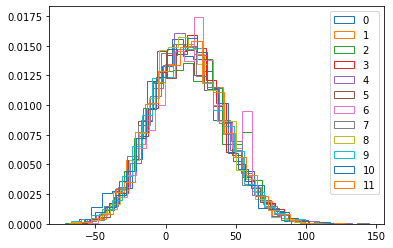

0.0017182872266514604


In [75]:
print("SGC P+B FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/SGC/data-SNsub-fatsP/fkp/1.0/chain.npy"))

In [76]:
chain = np.load(output + "SGC/data-SNsub-fatsP/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC FKP p=1
0.0017182872266514604
[-10.44517615  41.73180954]
[-35.31662399  66.64173044]


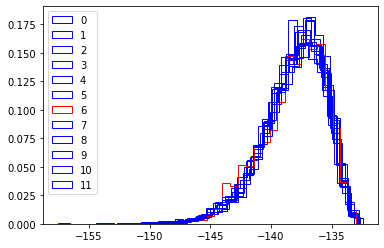

In [77]:
like = chain[:,14,:]

for i in range(12):
    if i in [6,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC optimal P p=1

SGC P+B p=1


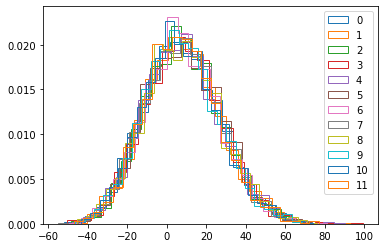

9.823721808133179e-05


In [78]:
print("SGC P+B p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/SGC/data-SNsub-fatsP/1.0/chain.npy"))

In [79]:
chain = np.load(output + "SGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [6,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC p=1
9.823721808133179e-05
[-11.09872919  27.13658038]
[-30.00382868  44.97439175]


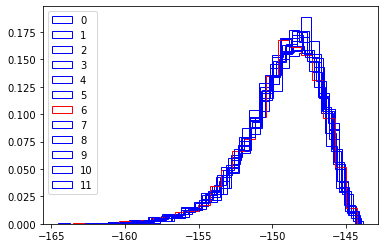

In [80]:
like = chain[:,14,:]

for i in range(12):
    if i in [6,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC FKP p=1.6

In [81]:
output = "bis-fits/output-PplusB-s3rebin/"

SGC P+B FKP p=1.6


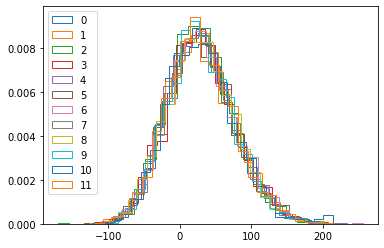

-4.192058330299009e-05


In [82]:
print("SGC P+B FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/SGC/data-SNsub-fatsP/fkp/1.6/chain.npy"))

In [83]:
chain = np.load(output + "SGC/data-SNsub-fatsP/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [7,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC FKP p=1.6
-4.192058330299009e-05
[-20.17350415  72.26511773]
[-60.45724322 122.77976763]


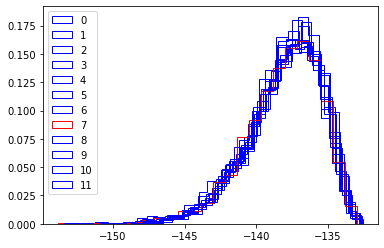

In [84]:
like = chain[:,14,:]

for i in range(12):
    if i in [7,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## SGC optimal P p=1.6

SGC P+B p=1.6


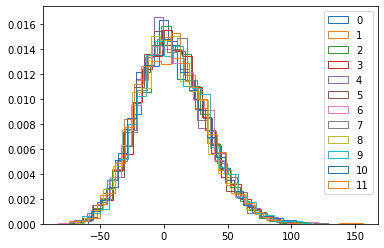

0.00033748544860867646


In [85]:
print("SGC P+B p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/SGC/data-SNsub-fatsP/1.6/chain.npy"))

In [86]:
chain = np.load(output + "SGC/data-SNsub-fatsP/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [6,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("SGC p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

SGC p=1.6
0.00033748544860867646
[-22.2960092   31.47516543]
[-43.09955488  62.87717912]


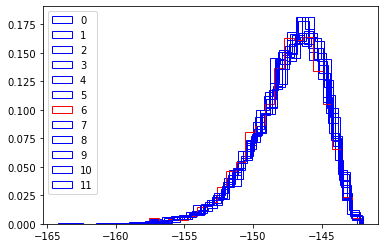

In [87]:
like = chain[:,14,:]

for i in range(12):
    if i in [6,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint FKP p=1

In [88]:
output = "bis-fits/output-PplusB-s3rebin/"

joint P+cB FKP p=1


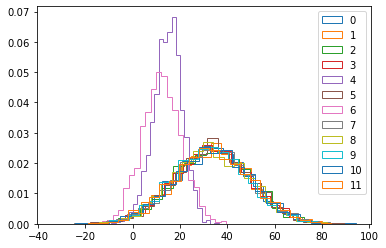

0.270675126935884


In [89]:
print("joint P+cB FKP p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/joint/data-SNsub/fkp/1.0/chain.npy"))

In [90]:
chain = np.load(output + "joint/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [4,6,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint FKP p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint FKP p=1
9.69457151325237e-05
[17.85579925 49.8359452 ]
[ 2.87497776 65.96988523]


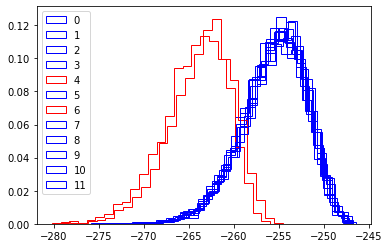

In [91]:
like = chain[:,23,:]

for i in range(12):
    if i in [6,4,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint optimal P p=1

joint P+cB p=1


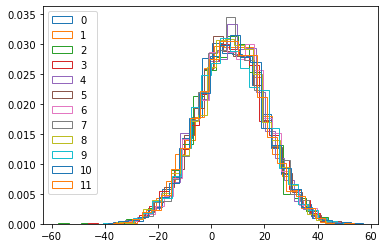

-0.00010567399922822851


In [92]:
print("joint P+cB p=1")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/joint/data-SNsub/1.0/chain.npy"))

In [93]:
chain = np.load(output + "joint/data-SNsub/1.0/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [9,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint p=1
-0.00010567399922822851
[-5.55907173 19.95218817]
[-17.99260047  32.60373588]


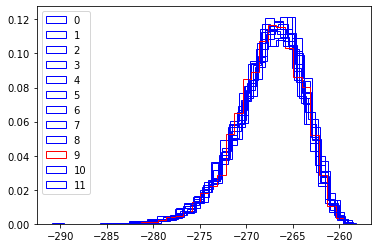

In [94]:
like = chain[:,23,:]

for i in range(12):
    if i in [9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint FKP p=1.6

In [95]:
output = "bis-fits/output-PplusB-s3rebin/"

joint P+cB FKP p=1.6


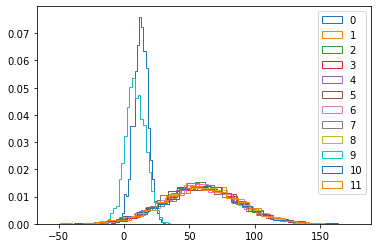

0.4877189217217499


In [96]:
print("joint P+cB FKP p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/joint/data-SNsub/fkp/1.6/chain.npy"))

In [97]:
chain = np.load(output + "joint/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

f_nl_chain = np.delete(f_nl_chain, [9,0,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint FKP p=1.6")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint FKP p=1.6
0.00024951679041884667
[31.34373744 88.91565437]
[ -0.45154332 115.76572042]


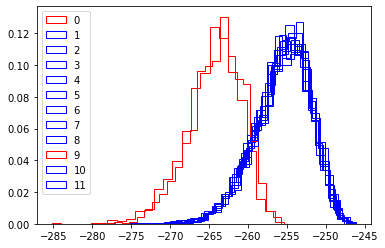

In [98]:
like = chain[:,23,:]

for i in range(12):
    if i in [0,9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

## Joint optimal P p=1.6

joint P+cB p=1.6


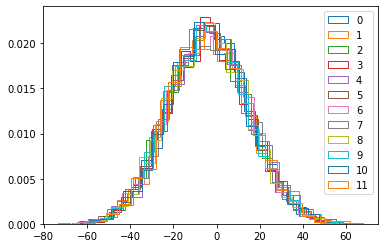

-8.116482247111367e-05


In [99]:
print("joint P+cB p=1.6")
hist_chain(np.load("bis-fits/output-PplusB-s3rebin/joint/data-SNsub/1.6/chain.npy"))

In [100]:
chain = np.load(output + "joint/data-SNsub/1.6/chain.npy")

f_nl_chain = chain[:,0,:]

#f_nl_chain = np.delete(f_nl_chain, [9,], 1)

R = pp.gelman_rubin_R(f_nl_chain)

print("joint p=1")
print(R - 1)

print(pp.confidence_interval(f_nl_chain.flatten(), 0.68))
print(pp.confidence_interval(f_nl_chain.flatten(), 0.95))

joint p=1
-8.116482247111367e-05
[-22.83566215  14.07046295]
[-40.0412813  32.6583438]


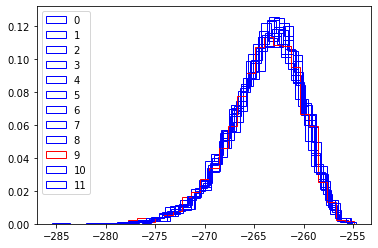

In [101]:
like = chain[:,23,:]

for i in range(12):
    if i in [9,]: color = 'r'
    else: color = 'b'
    plt.hist(like[:,i], bins=25, density=True, histtype='step', label=f'{i}', color=color)

plt.legend()
plt.show()

# Posterior comparison

## Comparing P, P+B $3 k_f$, and P+cB

In [102]:
output_PcB = "bis-fits/output-PplusB-compression/"
output_PB  = "bis-fits/output-PplusB-s3rebin/"
output_P   = "fits/output-fnl/"

### NGC

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


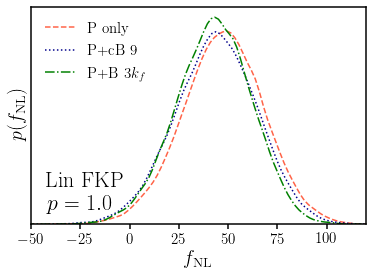

In [103]:
chain1 = np.load(output_P   + "NGC/fkp/1.0/chain.npy")
chain2 = np.load(output_PcB + "compression-9/NGC/data-SNsub/fkp/1.0/chain.npy")
chain3 = np.load(output_PB  + "NGC/data-SNsub-fatsP/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [0,11,], 1)

f_nl_chain3 = chain3[:,0,:]

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin FKP \n $p=1.0$", xy=(15,15), xlim=[-50, 120])

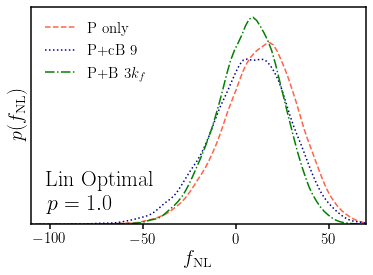

In [104]:
chain1 = np.load(output_P   + "NGC/1.0/chain.npy")
chain2 = np.load(output_PcB + "compression-9/NGC/data-SNsub/1.0/chain.npy")
chain3 = np.load(output_PB  + "NGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

f_nl_chain3 = chain3[:,0,:]
#f_nl_chain3 = np.delete(f_nl_chain3, [6,], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin Optimal \n $p=1.0$", xy=(15,15), xlim=[-110, 70])

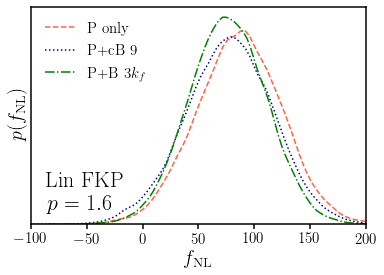

In [105]:
chain1 = np.load(output_P   + "NGC/fkp/1.6/chain.npy")
chain2 = np.load(output_PcB + "compression-9/NGC/data-SNsub/fkp/1.6/chain.npy")
chain3 = np.load(output_PB  + "NGC/data-SNsub-fatsP/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
#f_nl_chain2 = np.delete(f_nl_chain2, [2,], 1)

f_nl_chain3 = chain3[:,0,:]

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin FKP \n $p=1.6$", xy=(15,15), xlim=[-100, 200])

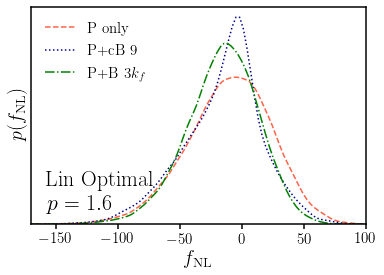

In [106]:
chain1 = np.load(output_P   + "NGC/1.6/chain.npy")
chain2 = np.load(output_PcB + "compression-9/NGC/data-SNsub/1.6/chain.npy")
chain3 = np.load(output_PB  + "NGC/data-SNsub-fatsP/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

f_nl_chain3 = chain3[:,0,:]
#f_nl_chain3 = np.delete(f_nl_chain3, [6,], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin Optimal \n $p=1.6$", xy=(15,15), xlim=[-170, 100])

 ### SGC

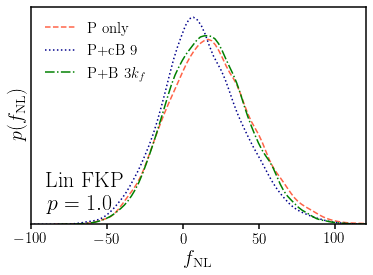

In [107]:
chain1 = np.load(output_P   + "SGC/fkp/1.0/chain.npy")
chain2 = np.load(output_PcB + "compression-9/SGC/data-SNsub/fkp/1.0/chain.npy")
chain3 = np.load(output_PB  + "SGC/data-SNsub-fatsP/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
#f_nl_chain2 = np.delete(f_nl_chain2, [0,11,], 1)

f_nl_chain3 = chain3[:,0,:]

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin FKP \n $p=1.0$", xy=(15,15), xlim=[-100, 120])

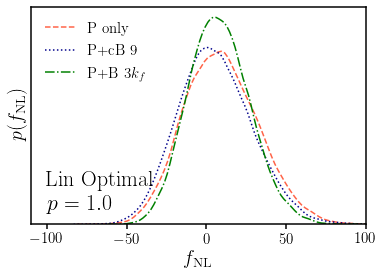

In [108]:
chain1 = np.load(output_P   + "SGC/1.0/chain.npy")
chain2 = np.load(output_PcB + "compression-9/SGC/data-SNsub/1.0/chain.npy")
chain3 = np.load(output_PB  + "SGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [2,], 1)

f_nl_chain3 = chain3[:,0,:]
#f_nl_chain3 = np.delete(f_nl_chain3, [6,], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin Optimal \n $p=1.0$", xy=(15,15), xlim=[-110, 100])

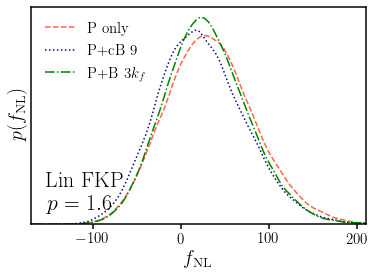

In [109]:
chain1 = np.load(output_P   + "SGC/fkp/1.6/chain.npy")
chain2 = np.load(output_PcB + "compression-9/SGC/data-SNsub/fkp/1.6/chain.npy")
chain3 = np.load(output_PB  + "SGC/data-SNsub-fatsP/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
#f_nl_chain2 = np.delete(f_nl_chain2, [2,], 1)

f_nl_chain3 = chain3[:,0,:]

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin FKP \n $p=1.6$", xy=(15,15), xlim=[-170, 210])

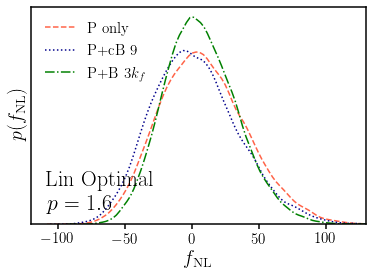

In [110]:
chain1 = np.load(output_P   + "SGC/1.6/chain.npy")
chain2 = np.load(output_PcB + "compression-9/SGC/data-SNsub/1.6/chain.npy")
chain3 = np.load(output_PB  + "SGC/data-SNsub-fatsP/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

f_nl_chain3 = chain3[:,0,:]
#f_nl_chain3 = np.delete(f_nl_chain3, [6,], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='P only', name2='P+cB 9', name3='P+B $3k_f$',
                                save=None, ci95=None, annotate="Lin Optimal \n $p=1.6$", xy=(15,15), xlim=[-120, 130])

 ### Joint

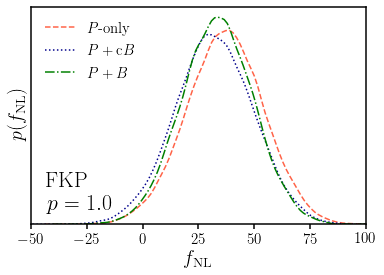

In [113]:
chain1 = np.load(output_P   + "joint/fkp/1.0/chain.npy")
chain2 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/fkp/1.0/chain.npy")
chain3 = np.load(output_PB  + "joint/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [4,2], 1)

f_nl_chain3 = chain3[:,0,:]
f_nl_chain3 = np.delete(f_nl_chain3, [4,6], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='$P$-only', name2='$P+{\\rm c}B$', name3='$P+B$',
                                save=None, ci95=None, annotate="FKP \n $p=1.0$", xy=(15,15), xlim=[-50, 100])

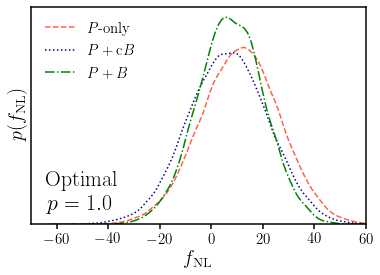

In [114]:
chain1 = np.load(output_P   + "joint/1.0/chain.npy")
chain2 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/1.0/chain.npy")
chain3 = np.load(output_PB  + "joint/data-SNsub/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [1,9], 1)

f_nl_chain3 = chain3[:,0,:]
#f_nl_chain3 = np.delete(f_nl_chain3, [6,], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='$P$-only', name2='$P+{\\rm c}B$', name3='$P+B$',
                                save=None, ci95=None, annotate="Optimal \n $p=1.0$",
                                 xy=(15,15), xlim=[-70, 60])

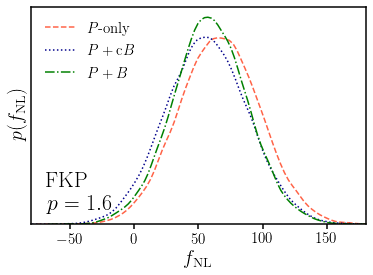

In [115]:
chain1 = np.load(output_P   + "joint/fkp/1.6/chain.npy")
chain2 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/fkp/1.6/chain.npy")
chain3 = np.load(output_PB  + "joint/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [3,], 1)

f_nl_chain3 = chain3[:,0,:]
f_nl_chain3 = np.delete(f_nl_chain3, [0,9], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='$P$-only', name2='$P+{\\rm c}B$', name3='$P+B$',
                                save=None, ci95=None, annotate="FKP \n $p=1.6$", 
                                 xy=(15,15), xlim=[-80, 180])

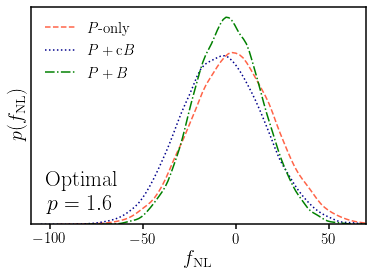

In [116]:
chain1 = np.load(output_P   + "joint/1.6/chain.npy")
chain2 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/1.6/chain.npy")
chain3 = np.load(output_PB  + "joint/data-SNsub/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [1,4], 1)

f_nl_chain3 = chain3[:,0,:]
#f_nl_chain3 = np.delete(f_nl_chain3, [6,], 1)

fNL_posterior_3comparison_smooth(f_nl_chain1, f_nl_chain2, f_nl_chain3, name1='$P$-only', name2='$P+{\\rm c}B$', name3='$P+B$',
                                save=None, ci95=None, annotate="Optimal \n $p=1.6$", 
                                 xy=(15,15), xlim=[-110, 70])

## P+B vs P+cB

### Joint

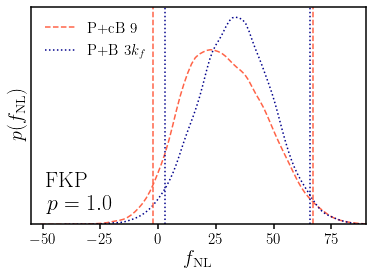

In [117]:
chain1 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/fkp/1.0/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [4,6,], 1)

ci95 = np.array([[-2,67],[3,66]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P+cB 9', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="FKP \n $p=1.0$", 
                                xy=(15,15), xlim=[-55, 90])

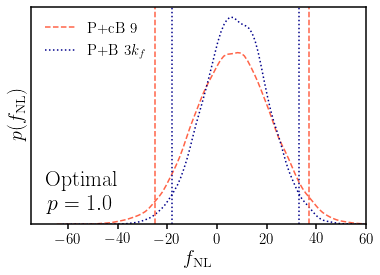

In [118]:
chain1 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/1.0/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]
f_nl_chain1 = np.delete(f_nl_chain1, [1,9,], 1)

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-25,37],[-18,33]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P+cB 9', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Optimal \n $p=1.0$", 
                                xy=(15,15), xlim=[-75, 60])

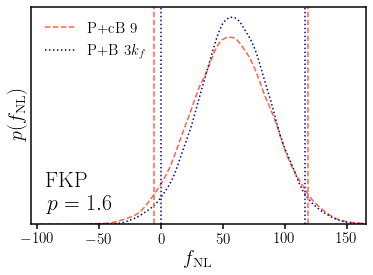

In [123]:
chain1 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/fkp/1.6/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]
f_nl_chain1 = np.delete(f_nl_chain1, [3,], 1)

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [0,9,], 1)

ci95 = np.array([[-6,118],[0,116]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P+cB 9', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="FKP \n $p=1.6$", 
                                xy=(15,15), xlim=[-105, 165])


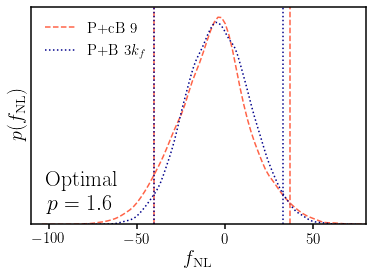

In [124]:
chain1 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/1.6/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-40,37],[-40,33]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P+cB 9', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Optimal \n $p=1.6$", 
                                xy=(15,15), xlim=[-110, 80])

## P-only vs P+B

In [125]:
output_PB  = "bis-fits/output-PplusB-s3rebin/"
output_P   = "fits/output-fnl/"

### NGC

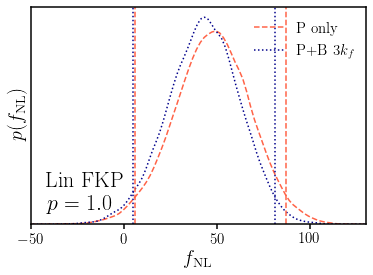

In [126]:
chain1 = np.load(output_P   + "NGC/fkp/1.0/chain.npy")
chain2 = np.load(output_PB  + "NGC/data-SNsub-fatsP/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[6,87],[5,81]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin FKP \n $p=1.0$", xy=(15,15), xlim=[-50, 130])

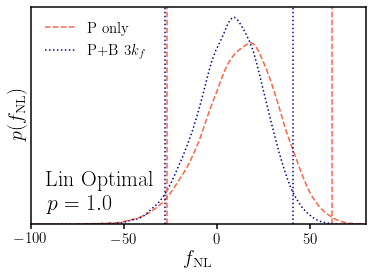

In [127]:
chain1 = np.load(output_P   + "NGC/1.0/chain.npy")
chain2 = np.load(output_PB  + "NGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-27,62],[-28,41]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin Optimal \n $p=1.0$", xy=(15,15), xlim=[-100, 80])

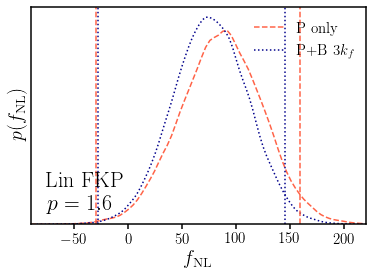

In [128]:
chain1 = np.load(output_P   + "NGC/fkp/1.6/chain.npy")
chain2 = np.load(output_PB  + "NGC/data-SNsub-fatsP/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-30,159],[-28,145]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin FKP \n $p=1.6$", xy=(15,15), xlim=[-90, 220])

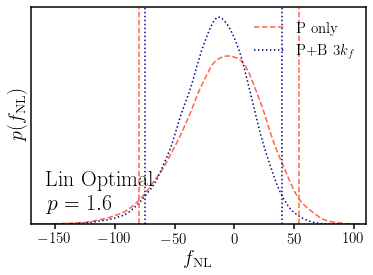

In [129]:
chain1 = np.load(output_P   + "NGC/1.6/chain.npy")
chain2 = np.load(output_PB  + "NGC/data-SNsub-fatsP/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-80,54],[-75,40]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin Optimal \n $p=1.6$", xy=(15,15), xlim=[-170, 110])

### SGC

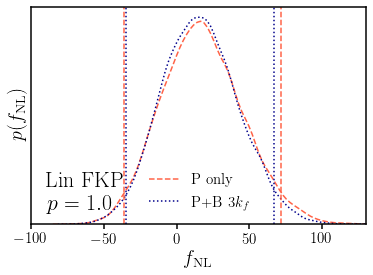

In [130]:
chain1 = np.load(output_P   + "SGC/fkp/1.0/chain.npy")
chain2 = np.load(output_PB  + "SGC/data-SNsub-fatsP/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-36,72],[-35,67]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin FKP \n $p=1.0$", xy=(15,15), xlim=[-100, 130])

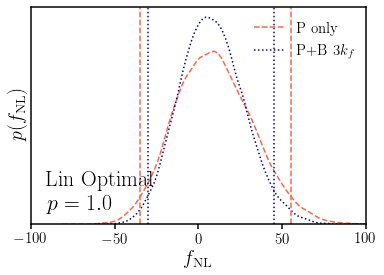

In [131]:
chain1 = np.load(output_P   + "SGC/1.0/chain.npy")
chain2 = np.load(output_PB  + "SGC/data-SNsub-fatsP/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-35,55],[-30,45]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin Optimal \n $p=1.0$", xy=(15,15), xlim=[-100, 100])

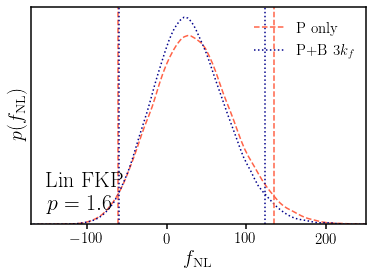

In [132]:
chain1 = np.load(output_P   + "SGC/fkp/1.6/chain.npy")
chain2 = np.load(output_PB  + "SGC/data-SNsub-fatsP/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-61,135],[-60,123]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin FKP \n $p=1.6$", xy=(15,15), xlim=[-170, 250])

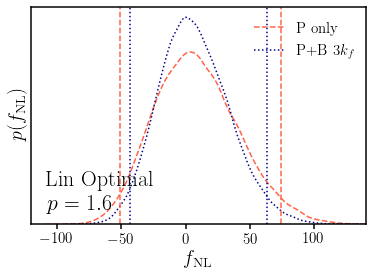

In [133]:
chain1 = np.load(output_P   + "SGC/1.6/chain.npy")
chain2 = np.load(output_PB  + "SGC/data-SNsub-fatsP/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-51,74],[-43,63]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Lin Optimal \n $p=1.6$", xy=(15,15), xlim=[-120, 140])

### Joint

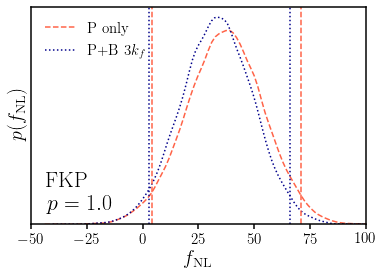

In [134]:
chain1 = np.load(output_P   + "joint/fkp/1.0/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/fkp/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [4,6,], 1)

ci95 = np.array([[4,71],[3,66]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="FKP \n $p=1.0$", 
                                xy=(15,15), xlim=[-50, 100])

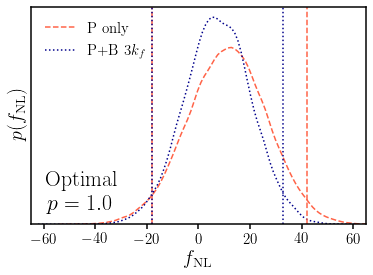

In [135]:
chain1 = np.load(output_P   + "joint/1.0/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/1.0/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-18,42],[-18,33]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Optimal \n $p=1.0$", 
                                xy=(15,15), xlim=[-65, 65])

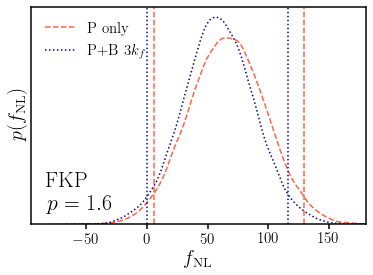

In [136]:
chain1 = np.load(output_P   + "joint/fkp/1.6/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/fkp/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]
f_nl_chain2 = np.delete(f_nl_chain2, [0,9,], 1)

ci95 = np.array([[6,129],[0,116]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="FKP \n $p=1.6$", 
                                xy=(15,15), xlim=[-95, 180])

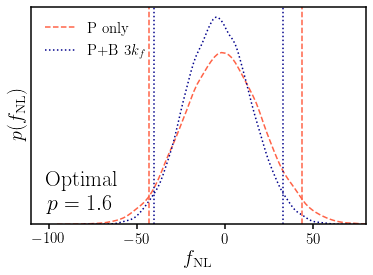

In [137]:
chain1 = np.load(output_P   + "joint/1.6/chain.npy")
chain2 = np.load(output_PB  + "joint/data-SNsub/1.6/chain.npy")

f_nl_chain1 = chain1[:,0,:]

f_nl_chain2 = chain2[:,0,:]

ci95 = np.array([[-43,44],[-40,33]])

fNL_posterior_comparison_smooth(f_nl_chain1, f_nl_chain2, name1='P only', name2='P+B $3k_f$',
                                save=None, ci95=ci95, annotate="Optimal \n $p=1.6$", 
                                xy=(15,15), xlim=[-110, 80])